In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
!unzip "/content/drive/MyDrive/Raya_AI/Photos_dataset.zip" -d "/content/Photos_dataset"

Archive:  /content/drive/MyDrive/Raya_AI/Photos_dataset.zip
replace /content/Photos_dataset/Photos_dataset/Ahmad_Gadalla/1.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/Photos_dataset/Photos_dataset/Ahmad_Gadalla/1.jpeg  
replace /content/Photos_dataset/Photos_dataset/Mohamed Ayman/WhatsApp Image 2026-07-30 at 12.22.02 AM (1).jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: /content/Photos_dataset/Photos_dataset/Mohamed Ayman/WhatsApp Image 2026-07-30 at 12.22.02 AM (1).jpeg  
replace /content/Photos_dataset/Photos_dataset/Ali_omar/ali3.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: a
error:  invalid response [a]
replace /content/Photos_dataset/Photos_dataset/Ali_omar/ali3.jpeg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A
  inflating: /content/Photos_dataset/Photos_dataset/Ali_omar/ali3.jpeg  
  inflating: /content/Photos_dataset/Photos_dataset/Ali_omar/ali1.jpeg  
  inflating: /content/Photos_dataset/Photos_dataset/Mohamed Ayman/WhatsApp Image 2026-07-30 at 12

In [37]:
import os
import random
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from PIL import Image

from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [38]:
dataset_path = "/content/Photos_dataset/Photos_dataset"

print(os.listdir(dataset_path))

['Ahmad_Gadalla', 'Lama Ataturk', 'Ali_omar', 'Mohamed Ayman']


In [39]:
dataset_path = "/content/Photos_dataset/Photos_dataset"

people = sorted(os.listdir(dataset_path))

print("Number of people:", len(people))
print()

for person in people:
    person_path = os.path.join(dataset_path, person)
    images = os.listdir(person_path)
    print(f"{person}: {len(images)} images")

Number of people: 4

Ahmad_Gadalla: 2 images
Ali_omar: 3 images
Lama Ataturk: 3 images
Mohamed Ayman: 2 images


Image size: (712, 663)
Image mode: RGB


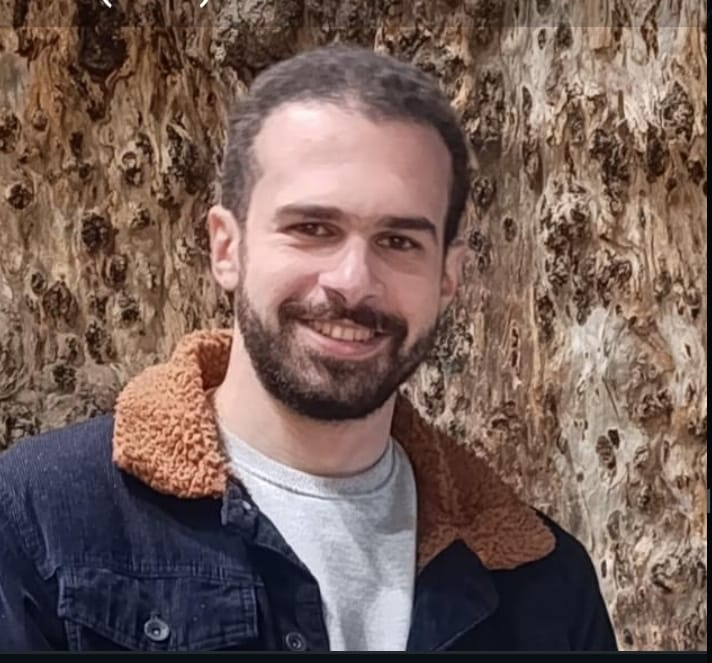

In [40]:
sample_person = people[0]

sample_image = os.listdir(os.path.join(dataset_path, sample_person))[0]

image_path = os.path.join(dataset_path, sample_person, sample_image)

img = Image.open(image_path)

print("Image size:", img.size)
print("Image mode:", img.mode)

img

In [41]:
# Dataset path
dataset_path = "/content/Photos_dataset/Photos_dataset"

# Resize all images to 224x224
IMG_SIZE = (224, 224)

# Lists to store images and labels
images = []
labels = []

# Read all images
for person in os.listdir(dataset_path):

    person_folder = os.path.join(dataset_path, person)

    if os.path.isdir(person_folder):

        for image_name in os.listdir(person_folder):

            image_path = os.path.join(person_folder, image_name)

            # Read image
            img = cv2.imread(image_path)

            # Skip if image cannot be read
            if img is None:
                continue

            # Convert from BGR to RGB
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # Resize
            img = cv2.resize(img, IMG_SIZE)

            # Normalize pixel values to [0,1]
            img = img / 255.0

            # Store
            images.append(img)
            labels.append(person)

# Convert to NumPy arrays
images = np.array(images, dtype=np.float32)
labels = np.array(labels)

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)
print("People:", np.unique(labels))

Images shape: (10, 224, 224, 3)
Labels shape: (10,)
People: ['Ahmad_Gadalla' 'Ali_omar' 'Lama Ataturk' 'Mohamed Ayman']


In [42]:
from collections import defaultdict

# Dictionary: person -> list of image indices
person_to_indices = defaultdict(list)

for i, label in enumerate(labels):
    person_to_indices[label].append(i)

# Display the image indices for each person
for person, indices in person_to_indices.items():
    print(f"{person}: {indices}")

Ahmad_Gadalla: [0, 1]
Lama Ataturk: [2, 3, 4]
Ali_omar: [5, 6, 7]
Mohamed Ayman: [8, 9]


In [43]:
pair_images_1 = []
pair_images_2 = []
pair_labels = []

people = list(person_to_indices.keys())

for person in people:

    indices = person_to_indices[person]

    # ---------- Positive Pairs ----------
    if len(indices) >= 2:
        for i in range(len(indices)):
            for j in range(i + 1, len(indices)):

                pair_images_1.append(images[indices[i]])
                pair_images_2.append(images[indices[j]])
                pair_labels.append(1)

    # ---------- Negative Pairs ----------
    for idx in indices:

        # Choose another person randomly
        other_person = random.choice([p for p in people if p != person])

        other_idx = random.choice(person_to_indices[other_person])

        pair_images_1.append(images[idx])
        pair_images_2.append(images[other_idx])
        pair_labels.append(0)

# Convert to NumPy arrays
pair_images_1 = np.array(pair_images_1)
pair_images_2 = np.array(pair_images_2)
pair_labels = np.array(pair_labels)

print("Total pairs:", len(pair_labels))
print("Positive pairs:", np.sum(pair_labels == 1))
print("Negative pairs:", np.sum(pair_labels == 0))

Total pairs: 18
Positive pairs: 8
Negative pairs: 10


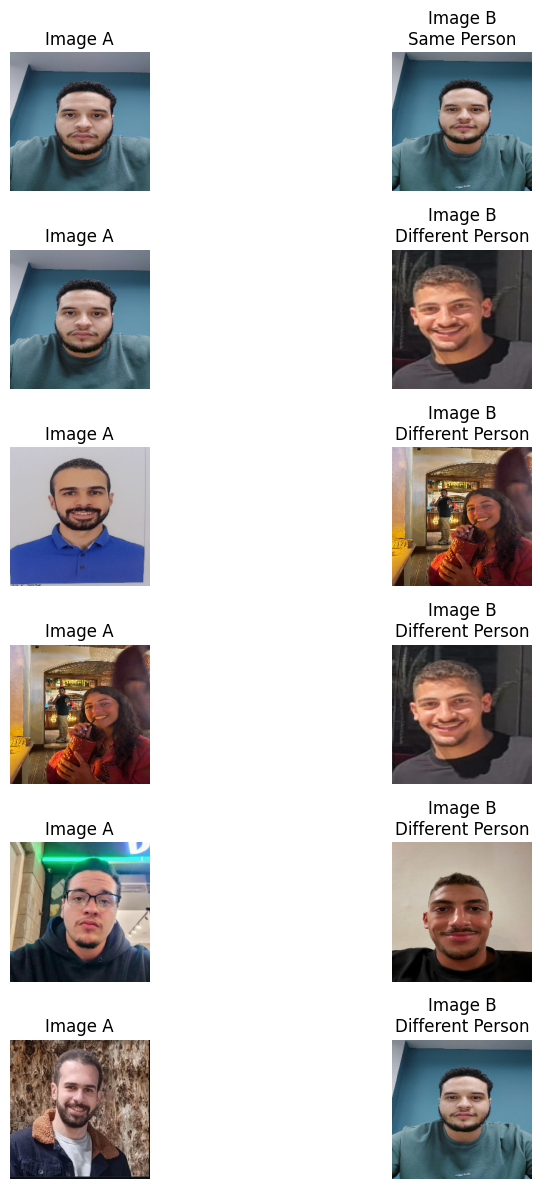

In [44]:
# Show 6 random pairs
plt.figure(figsize=(10, 12))

for i in range(6):

    idx = random.randint(0, len(pair_labels) - 1)

    plt.subplot(6, 2, 2*i + 1)
    plt.imshow(pair_images_1[idx])
    plt.axis("off")
    plt.title("Image A")

    plt.subplot(6, 2, 2*i + 2)
    plt.imshow(pair_images_2[idx])
    plt.axis("off")

    if pair_labels[idx] == 1:
        plt.title("Image B\nSame Person")
    else:
        plt.title("Image B\nDifferent Person")

plt.tight_layout()
plt.show()

In [45]:
# Split the pairs
X1_train, X1_test, X2_train, X2_test, y_train, y_test = train_test_split(
    pair_images_1,
    pair_images_2,
    pair_labels,
    test_size=0.2,
    random_state=42,
    stratify=pair_labels
)

print("Training pairs:", len(y_train))
print("Testing pairs:", len(y_test))

Training pairs: 14
Testing pairs: 4


In [21]:
# Load MobileNetV2 without its final classification layer
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze pretrained weights
base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [46]:
input_img = layers.Input(shape=(224,224,3))


x = base_model(input_img, training=False)

x = layers.GlobalAveragePooling2D()(x)

embedding = layers.Dense(
    128,
    activation="relu"
)(x)


embedding_network = Model(
    input_img,
    embedding,
    name="Embedding_Network"
)


embedding_network.summary()

Model: "Embedding_Network"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [47]:
input_a = layers.Input(shape=(224,224,3), name="image_A")

input_b = layers.Input(shape=(224,224,3), name="image_B")

In [48]:
embedding_a = embedding_network(input_a)

embedding_b = embedding_network(input_b)

In [49]:
distance = layers.Lambda(
    lambda tensors: tf.sqrt(
        tf.reduce_sum(
            tf.square(tensors[0]-tensors[1]),
            axis=1,
            keepdims=True
        )
    )
)([embedding_a, embedding_b])

In [50]:
siamese_model = Model(
    inputs=[input_a,input_b],
    outputs=distance
)


siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_A             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_B             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding_Network   │ (None, 128)       │  2,421,952 │ image_A[0][0],    │
│ (Functional)        │                   │            │ image_B[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ Embedding_Networ… │
│                     │                   │            │ Embedding_Networ… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [51]:
def contrastive_loss(y_true, y_pred):

    margin = 1

    loss = (
        y_true * tf.square(y_pred)
        +
        (1-y_true) *
        tf.square(
            tf.maximum(margin-y_pred,0)
        )
    )

    return tf.reduce_mean(loss)

In [52]:
siamese_model.compile(
    optimizer="adam",
    loss=contrastive_loss
)

In [53]:
siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_A             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ image_B             │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Embedding_Network   │ (None, 128)       │  2,421,952 │ image_A[0][0],    │
│ (Functional)        │                   │            │ image_B[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 1)         │          0 │ Embedding_Networ… │
│                     │                   │            │ Embedding_Networ… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,421,952 (9.24 MB)

 Trainable params: 163,968 (640.50 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [54]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)


history = siamese_model.fit(
    [X1_train, X2_train],
    y_train,
    validation_data=([X1_test, X2_test], y_test),
    epochs=30,
    batch_size=4,
    callbacks=[early_stop]
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 33s 6s/step - loss: 13.6106 - val_loss: 4.3972
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - loss: 4.2688 - val_loss: 1.2861
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - loss: 0.9762 - val_loss: 0.3756
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 0.6972 - val_loss: 0.1868
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - loss: 0.6617 - val_loss: 0.4181
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 0.3343 - val_loss: 0.4101
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step - loss: 0.3811 - val_loss: 0.3414
Epoch 8/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - loss: 0.2444 - val_loss: 0.1258
Epoch 9/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - loss: 0.1416 - val_loss: 0.0928
Epoch 10/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.1159 - val_loss: 0.0714
Epoch 11/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - loss: 0.1024 - val_loss: 0.0719
Epoch 12/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - loss: 0.0668 - val_loss: 0.0486
E

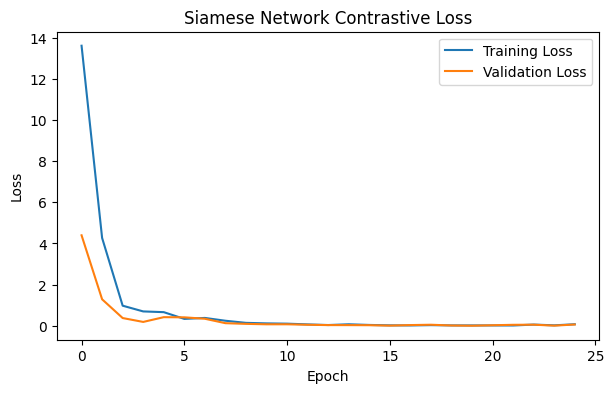

In [55]:
plt.figure(figsize=(7,4))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Siamese Network Contrastive Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [56]:
# Get distances from test pairs

distances = siamese_model.predict(
    [X1_test, X2_test]
)


distances = distances.flatten()


# Convert distances into predictions

threshold = 0.5

y_pred = (distances < threshold).astype(int)


print("Distances:")
print(distances)

print("\nTrue labels:")
print(y_test)

print("\nPredicted labels:")
print(y_pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
Distances:
[2.2378619 0.0622945 1.9432662 0.0738175]

True labels:
[0 1 0 1]

Predicted labels:
[0 1 0 1]


In [57]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred)

recall = recall_score(y_test, y_pred)

f1 = f1_score(y_test, y_pred)


print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1 Score: 1.0


In [58]:
# Create a database of known face embeddings

face_database = {}

for person, indices in person_to_indices.items():

    person_embeddings = []

    for idx in indices:

        img = np.expand_dims(images[idx], axis=0)

        embedding = embedding_network.predict(
            img,
            verbose=0
        )

        person_embeddings.append(embedding[0])


    # Store the average embedding for each person
    face_database[person] = np.mean(
        person_embeddings,
        axis=0
    )


print(face_database.keys())

dict_keys([np.str_('Ahmad_Gadalla'), np.str_('Lama Ataturk'), np.str_('Ali_omar'), np.str_('Mohamed Ayman')])


In [59]:
def recognize_face(query_image, threshold=0.5):

    # Convert image to batch format
    query_image = np.expand_dims(query_image, axis=0)

    # Get query embedding
    query_embedding = embedding_network.predict(
        query_image,
        verbose=0
    )[0]


    best_person = None
    best_distance = float("inf")


    # Compare with stored faces
    for person, stored_embedding in face_database.items():

        distance = np.linalg.norm(
            query_embedding - stored_embedding
        )


        print(
            person,
            "distance:",
            round(distance,4)
        )


        if distance < best_distance:
            best_distance = distance
            best_person = person


    # Recognition decision
    if best_distance < threshold:
        result = best_person
    else:
        result = "Unknown"


    print("\nPrediction:", result)
    print("Similarity distance:", round(best_distance,4))

    return result

In [60]:
recognize_face(images[2])

Ahmad_Gadalla distance: 1.8725
Lama Ataturk distance: 0.0682
Ali_omar distance: 1.8052
Mohamed Ayman distance: 2.2615

Prediction: Lama Ataturk
Similarity distance: 0.0682


np.str_('Lama Ataturk')

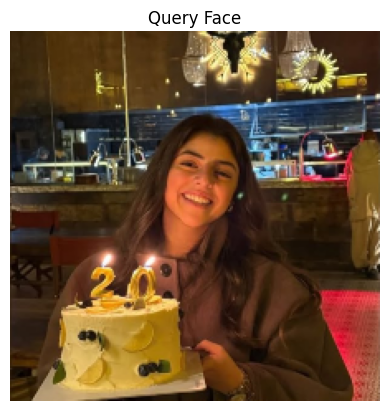

In [61]:
plt.imshow(images[2])
plt.axis("off")
plt.title("Query Face")
plt.show()

Ahmad_Gadalla distance: 1.8725
Lama Ataturk distance: 0.0682
Ali_omar distance: 1.8052
Mohamed Ayman distance: 2.2615

Prediction: Lama Ataturk
Similarity distance: 0.0682


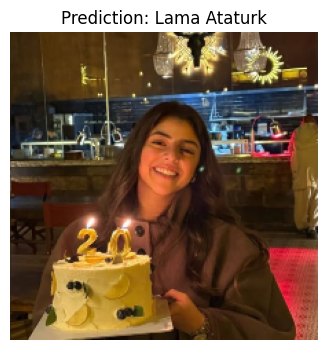

In [62]:
import matplotlib.pyplot as plt

def show_recognition_result(query_image):

    prediction = recognize_face(query_image)

    plt.figure(figsize=(4,4))

    plt.imshow(query_image)
    plt.axis("off")
    plt.title(f"Prediction: {prediction}")

    plt.show()


show_recognition_result(images[2])